# UV Photon Output — Single Pop III Star

**Input:** stellar mass $M$ (in $M_\odot$).
**Output:** total number of hydrogen-ionizing (Lyman-continuum, $h\nu \geq 13.6$ eV) photons
emitted by that star over its **main-sequence** lifetime, $N_{\rm UV}$.

## Method

1. **Stellar evolution data.** For a given mass $M$, load the corresponding MESA profile
   history file `profile_{M}.csv` from `Profiles/profile_csv/`. Each row is a MESA timestep
   giving `star_age` [yr], `log_Teff` [log10 K], `log_L` [log10 L_sun], `center_h1`
   (central hydrogen mass fraction), and `radius` [R_sun].

2. **Main-sequence window.** The main sequence (MS) runs from the first row (ZAMS,
   `star_age` ≈ 0) to the terminal-age main sequence (TAMS), defined here as the **first
   row where `center_h1 < 1e-3`**. Rows beyond that point (post-MS: subgiant/giant branch,
   etc.) are excluded — profile files in this dataset continue evolving the star for a long
   time after core-H exhaustion, so this cutoff matters a lot (e.g. `profile_1.0.csv` ends
   6 Gyr later on the giant branch).

3. **File resolution.** Only the plain filename `profile_{M}.csv` is ever used. Some masses
   also have suffixed variant files (e.g. `profile_150.0_1.csv`); these are **never** loaded,
   even as a fallback — at least one (`profile_150.0_1.csv`) is non-monotonic in `center_h1`
   (dips below the TAMS threshold, then rises again before the file ends), so falling back to
   suffixed files isn't trustworthy. If a mass has no plain file, it's simply unavailable.

4. **Incomplete / malformed runs.** `profile_87.0.csv` is missing the `radius` column
   entirely and has no plain-file alternative, so it's **ignored**: the loader raises an
   error rather than silently returning a partial/undercounted answer. (Batching over many
   masses, with explicit skip-and-report handling for cases like this, is left for a later
   step.)

5. **Lifetime segmentation.** $L$ and $T_{\rm eff}$ change continuously over the MS, and the
   raw MESA timesteps are irregular (as few as ~45 rows for some masses, densely spaced near
   ZAMS/TAMS and sparse in between). To integrate on a controlled, even footing across all
   masses, the MS duration $[0, t_{\rm TAMS}]$ is divided into `N_SEGMENTS` (default 100)
   **equal-time segments** (101 edge points). `log_Teff`, `log_L`, and `log10(radius)` are
   linearly interpolated from the native MESA grid onto these 101 edge times.

6. **Blackbody photon emission.** At each of the 101 segment-edge times the star is treated
   as a blackbody photosphere at temperature $T_{\rm eff}(t)$ and radius $R(t)$ (interpolated
   as above), with the Planck photon number density spectrum

   $$n(\varepsilon,\Theta) = \frac{8\pi}{\lambda_C^3}\,\frac{\varepsilon^2}{e^{\varepsilon/\Theta}-1},
   \qquad \varepsilon = \frac{E}{m_e c^2},\quad \Theta = \frac{k_B T_{\rm eff}}{m_e c^2}$$

   The emergent ionizing photon rate is (surface area) × (isotropic effusion flux $c\,n/4$),
   integrated above the ionization threshold:

   $$\dot N_{\rm ion}(t) = 4\pi R(t)^2 \cdot \frac{c}{4} \int_{\varepsilon_{\rm th}}^{\infty} n(\varepsilon, \Theta(t))\,d\varepsilon
   = \pi R(t)^2 c \int_{\varepsilon_{\rm th}}^{\infty} n(\varepsilon, \Theta(t))\,d\varepsilon,
   \qquad \varepsilon_{\rm th} = \frac{13.6\ {\rm eV}}{m_e c^2}$$

   **Note on this vs. `popIII_energy_density_summer.ipynb`.** That notebook's
   `photon_rate_per_energy` uses $4\pi R^2 c\int n\,d\varepsilon$ (no $c/4$), which — checked
   directly against its own $T_\star$/$R_\star$ via Stefan-Boltzmann — over-counts the total
   emitted power by a factor of essentially exactly 4 relative to $4\pi R^2\sigma T^4$. The
   $c/4$ factor above is the standard isotropic-blackbody-surface effusion flux (the same
   factor already implicitly built into $\sigma$ for the energy version). This notebook
   includes the correction; `popIII_energy_density_summer.ipynb` was intentionally left
   unchanged pending separate review, so **don't directly compare absolute $N_{\rm UV}$
   values against quantities derived from that notebook** — they differ by ~4×.

7. **Per-segment counting and summing.** Each of the 100 segments $i$ (bounded by edge times
   $t_i, t_{i+1}$) contributes a photon count via the trapezoidal rule on its own two edge
   rates, and the total is the sum over all segments:

   $$\Delta N_i = \tfrac{1}{2}\bigl(\dot N_{\rm ion}(t_i) + \dot N_{\rm ion}(t_{i+1})\bigr)\,(t_{i+1}-t_i)
   \qquad\Longrightarrow\qquad
   N_{\rm UV} = \sum_{i=0}^{99} \Delta N_i$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import quad


## Physical Constants

SI units unless noted. Same values as `popIII_energy_density_summer.ipynb`.

In [2]:
# Physical constants (SI units, CODATA to 3 dp — matches popIII_energy_density_summer.ipynb)
pi = np.pi
h  = 6.626e-34   # Planck constant [J s]
kB = 1.381e-23   # Boltzmann constant [J/K]
e  = 1.602e-19   # elementary charge [C] / eV -> J conversion
me = 9.109e-31   # electron mass [kg]
c  = 2.998e8     # speed of light [m/s]

M_sun = 1.989e30   # [kg]
R_sun = 6.957e8    # [m]
L_sun = 3.828e26   # [W]

sigma_SB    = 5.670e-8              # Stefan-Boltzmann constant [W m^-2 K^-4]
lambda_C    = h / (me * c)          # Compton wavelength [m]
sec_per_yr  = 365.25 * 24 * 3600    # seconds per year

def ev_to_eps(E_eV):
    """Convert photon energy [eV] to dimensionless epsilon = E / (m_e c^2)."""
    return np.asarray(E_eV, dtype=float) * e / (me * c**2)


## Configuration

In [3]:
PROFILE_DIR       = Path("/Users/igeondong/KCL/Project/Profiles/profile_csv")
H1_TAMS_THRESHOLD = 1e-3    # center_h1 threshold defining the end of the main sequence
E_ION_eV          = 13.6    # hydrogen (Lyman-continuum) ionization threshold [eV]
N_SEGMENTS        = 100     # number of equal-time segments the MS lifetime is divided into


## Blackbody Photon Emission

In [4]:
def inv_expm1_stable(x, x_switch=50.0):
    """1/(e^x - 1), stable for all x: uses expm1 for small x, exp(-x) in the Wien tail."""
    x = np.asarray(x, dtype=float)
    return np.where(x < x_switch, 1.0 / np.expm1(np.minimum(x, x_switch)), np.exp(-x))


def photon_density(eps, Theta):
    """Planck photon number density: n(eps) = (8*pi/lambda_C^3) * eps^2 / (e^(eps/Theta)-1)."""
    return (8 * pi / lambda_C**3) * eps**2 * inv_expm1_stable(eps / Theta)


def lyman_continuum_rate(Teff_K, R_Rsun, E_th_eV=E_ION_eV):
    """Instantaneous hydrogen-ionizing (Lyman-continuum) photon emission rate
    Q [photons s^-1] for a blackbody photosphere of temperature Teff_K [K] and
    radius R_Rsun [R_sun].

    Q = (surface area) * (isotropic effusion flux c/4) * integral[n(eps,Theta) deps]
      = 4*pi*R^2 * (c/4) * integral[...] = pi*R^2*c * integral[...]
    The c/4 factor is the standard blackbody-surface effusion flux for an isotropic
    photon field (the same factor already implicit in sigma_SB for the energy
    version, L=4*pi*R^2*sigma*T^4) — checked directly: without it, integrating this
    formula's energy-equivalent over the full spectrum overshoots 4*pi*R^2*sigma*T^4
    by a factor of ~4.

    The integral is done in the dimensionless variable x = eps/Theta (rather
    than eps directly) so that the integration domain is always O(1)-scaled;
    integrating eps from eps_th to infinity directly is numerically unstable
    when eps_th/Theta is very large or very small (quad fails to converge)."""
    Theta  = Teff_K * kB / (me * c**2)
    R      = R_Rsun * R_sun
    eps_th = ev_to_eps(E_th_eV)
    x_th   = eps_th / Theta
    prefactor = pi * R**2 * c * (8 * pi / lambda_C**3) * Theta**3
    integrand = lambda x: x**2 * inv_expm1_stable(x)
    I, _ = quad(integrand, x_th, np.inf, limit=200)
    return prefactor * I


## MESA Profile Loading

In [5]:
def resolve_profile_path(mass, profile_dir=PROFILE_DIR):
    """Locate the profile CSV for a given mass [M_sun].

    Only the plain file (profile_{mass}.csv) is ever used — suffixed variants
    (profile_{mass}_1.csv, _2.csv, ...) are never loaded, even as a fallback.
    At least one such file (profile_150.0_1.csv) is non-monotonic in center_h1
    (dips below the TAMS threshold, then rises again before the file ends), so
    falling back to a suffixed file isn't trustworthy; if the plain file is
    missing, the mass is simply unavailable."""
    mass_str = f"{float(mass):.1f}"
    plain = profile_dir / f"profile_{mass_str}.csv"
    if plain.exists():
        return plain
    raise FileNotFoundError(
        f"No plain profile CSV found for mass={mass} M_sun in {profile_dir} "
        f"(looked for profile_{mass_str}.csv; suffixed variants are intentionally not used)."
    )


def load_main_sequence(path, h1_threshold=H1_TAMS_THRESHOLD):
    """Load a profile CSV and return only the rows from ZAMS (row 0) up to and
    including the first row where center_h1 < h1_threshold (TAMS).
    Raises ValueError if the run never reaches that threshold (incomplete run —
    per instructions, these are ignored rather than silently under-integrated),
    or if a required column is missing from the file (e.g. profile_87.0.csv has
    no 'radius' column)."""
    df = pd.read_csv(path)
    required = {"star_age", "log_Teff", "log_L", "center_h1", "radius"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path.name}: missing required column(s) {sorted(missing)} — cannot compute.")
    below = df.index[df["center_h1"] < h1_threshold]
    if len(below) == 0:
        raise ValueError(
            f"{path.name}: center_h1 never drops below {h1_threshold:g} "
            f"(final center_h1={df['center_h1'].iloc[-1]:.4g}) — this run stops mid-MS "
            "and is being ignored rather than under-integrated."
        )
    tams_idx = below[0]
    return df.iloc[: tams_idx + 1].reset_index(drop=True)


## Lifetime Segmentation

The MS duration is divided into `n_segments` equal-time segments (n_segments+1 edge points, from ZAMS at t=0 to TAMS). `log_Teff`, `log_L`, and `log10(radius)` are linearly interpolated from the native (irregular) MESA age grid onto these edge times, so that every mass is integrated on the same, controlled time resolution regardless of how many raw MESA rows its profile file happens to contain.

In [6]:
def resample_ms_evolution(ms_df, n_segments=N_SEGMENTS):
    """Resample a main-sequence DataFrame (as returned by load_main_sequence) onto
    n_segments equal-time segments spanning ZAMS (t=0) to TAMS.

    Interpolation is linear-in-age on log_Teff, log_L, and log10(radius) (i.e.
    log-space in the evolving quantities, linear in time). Returns a dict with
    n_segments+1 points: t_yr, t_s, Teff [K], L [W], R [R_sun]."""
    t_src      = ms_df["star_age"].values
    logTeff_src = ms_df["log_Teff"].values
    logL_src    = ms_df["log_L"].values
    logR_src    = np.log10(ms_df["radius"].values)

    t_yr = np.linspace(t_src[0], t_src[-1], n_segments + 1)   # n_segments+1 edge points
    logTeff = np.interp(t_yr, t_src, logTeff_src)
    logL    = np.interp(t_yr, t_src, logL_src)
    logR    = np.interp(t_yr, t_src, logR_src)

    return dict(
        t_yr=t_yr,
        t_s=t_yr * sec_per_yr,
        Teff=10.0 ** logTeff,
        L=10.0 ** logL * L_sun,
        R=10.0 ** logR,
    )


## Total UV Photon Output for a Single Star

In [7]:
def compute_total_UV_photons(mass, h1_threshold=H1_TAMS_THRESHOLD, n_segments=N_SEGMENTS,
                              profile_dir=PROFILE_DIR, return_details=False):
    """Total number of Lyman-continuum (UV, E >= 13.6 eV) photons emitted by a
    single star of mass `mass` [M_sun] over its main-sequence lifetime.

    The MS lifetime is divided into n_segments equal-time segments; the ionizing
    photon rate is evaluated at each of the n_segments+1 segment edges, each
    segment's photon count is found via the trapezoidal rule on its two edge
    rates, and the total is the sum over all segments.

    Returns N_UV [photons] (float), or (N_UV, details_dict) if return_details=True.
    """
    path = resolve_profile_path(mass, profile_dir)
    ms   = load_main_sequence(path, h1_threshold)
    grid = resample_ms_evolution(ms, n_segments)

    Q = np.array([lyman_continuum_rate(T, Rv)
                  for T, Rv in zip(grid["Teff"], grid["R"])])   # [photons/s], one per edge point

    dt_seg        = np.diff(grid["t_s"])                        # duration of each segment [s]
    N_per_segment = 0.5 * (Q[:-1] + Q[1:]) * dt_seg              # trapezoidal photon count per segment
    N_UV          = np.sum(N_per_segment)                        # total = sum over all segments

    if return_details:
        details = dict(path=path, mass=mass, n_segments=n_segments,
                        t_yr=grid["t_yr"], t_s=grid["t_s"], Teff=grid["Teff"],
                        L=grid["L"], R=grid["R"], Q=Q,
                        N_per_segment=N_per_segment, ms=ms)
        return N_UV, details
    return N_UV


## Example: single-mass run

In [8]:
demo_mass = 100.0  # M_sun

N_UV, details = compute_total_UV_photons(demo_mass, return_details=True)

print(f"Mass                    = {demo_mass:g} M_sun")
print(f"Profile file            = {details['path'].name}")
print(f"Segments (edges)        = {details['n_segments']} ({details['n_segments']+1} edge points)")
print(f"MS duration (t_TAMS)    = {details['t_yr'][-1]:.4g} yr")
print(f"Total UV photons N_UV   = {N_UV:.6e}  photons")
print()
print("First 5 segments (edge age [yr], Teff [K], R [R_sun], segment photon count):")
for i in range(5):
    print(f"  seg {i:3d}:  t={details['t_yr'][i]:10.4g} yr  "
          f"Teff={details['Teff'][i]:9.4g} K  R={details['R'][i]:9.4g} R_sun  "
          f"dN={details['N_per_segment'][i]:.4e}")


Mass                    = 100 M_sun
Profile file            = profile_100.0.csv
Segments (edges)        = 100 (101 edge points)
MS duration (t_TAMS)    = 2.853e+06 yr
Total UV photons N_UV   = 1.110144e+64  photons

First 5 segments (edge age [yr], Teff [K], R [R_sun], segment photon count):
  seg   0:  t=     1e-05 yr  Teff=4.072e+04 K  R=    22.95 R_sun  dN=7.5544e+61
  seg   1:  t= 2.853e+04 yr  Teff= 9.57e+04 K  R=     4.18 R_sun  dN=8.7216e+61
  seg   2:  t= 5.706e+04 yr  Teff=9.392e+04 K  R=    4.327 R_sun  dN=8.7511e+61
  seg   3:  t= 8.559e+04 yr  Teff=9.318e+04 K  R=    4.405 R_sun  dN=8.8003e+61
  seg   4:  t= 1.141e+05 yr  Teff=9.282e+04 K  R=    4.447 R_sun  dN=8.8443e+61


## Verification

**1. Self-consistency check.** The blackbody bolometric luminosity
$L_{\rm SB}(t) = 4\pi R(t)^2 \sigma_{\rm SB} T_{\rm eff}(t)^4$, evaluated at the same
interpolated $R(t)$, $T_{\rm eff}(t)$ used for the photon-rate calculation, should reproduce
the interpolated MESA `log_L` column — this checks that interpolation and units are
consistent (not a re-derivation of the ionizing-photon physics).

**2. Segment-count convergence.** `N_UV` should stop changing (converge) as `n_segments`
increases, confirming 100 segments is a fine enough resolution of the MS lifetime.


Max |relative error| between blackbody L and interpolated MESA log_L: 6.603e-05
Mean |relative error|:                                                6.603e-05

Segment-count convergence check:
  n_segments=  20:  N_UV = 1.105054e+64  (rel. change from n=100: -4.585e-03)
  n_segments=  50:  N_UV = 1.109009e+64  (rel. change from n=100: -1.022e-03)
  n_segments= 100:  N_UV = 1.110144e+64  (rel. change from n=100: +0.000e+00)
  n_segments= 200:  N_UV = 1.110909e+64  (rel. change from n=100: +6.895e-04)


  n_segments= 400:  N_UV = 1.111185e+64  (rel. change from n=100: +9.383e-04)


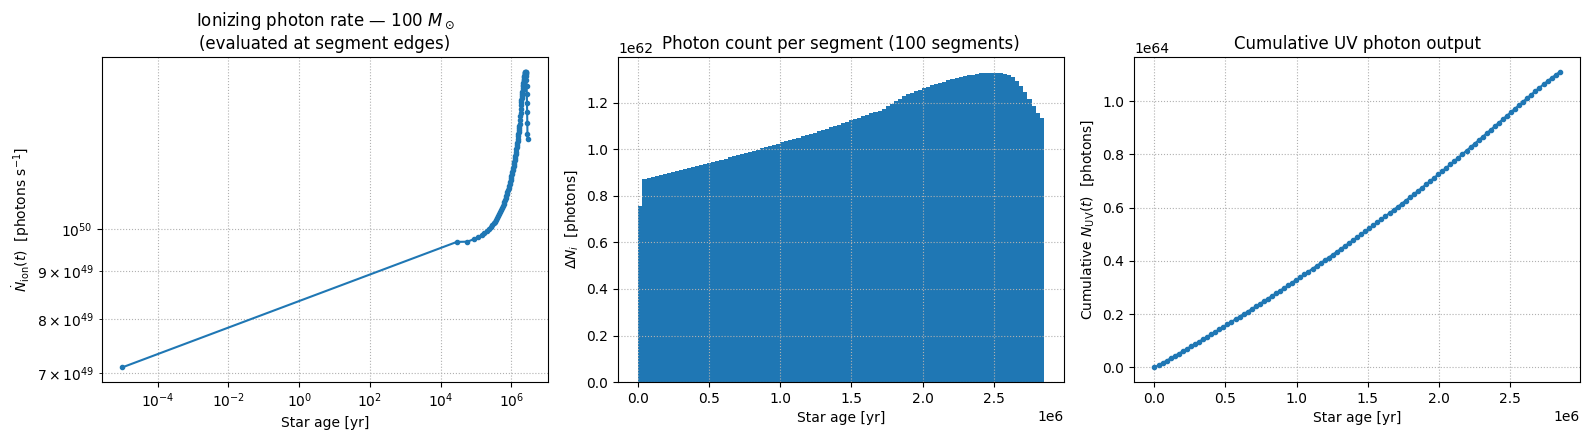

In [9]:
L_sb    = 4 * pi * (details["R"] * R_sun)**2 * sigma_SB * details["Teff"]**4   # [W]
L_mesa  = details["L"]                                                                 # [W]
rel_err = (L_sb - L_mesa) / L_mesa

print(f"Max |relative error| between blackbody L and interpolated MESA log_L: {np.max(np.abs(rel_err)):.3e}")
print(f"Mean |relative error|:                                                {np.mean(np.abs(rel_err)):.3e}")
print()

# Convergence check: recompute N_UV at a few different segment counts
print("Segment-count convergence check:")
for n in [20, 50, 100, 200, 400]:
    N_n = compute_total_UV_photons(demo_mass, n_segments=n)
    print(f"  n_segments={n:4d}:  N_UV = {N_n:.6e}  (rel. change from n=100: {(N_n - N_UV)/N_UV:+.3e})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].loglog(details["t_yr"], details["Q"], marker=".")
axes[0].set_xlabel("Star age [yr]")
axes[0].set_ylabel(r"$\dot N_{\rm ion}(t)$  [photons s$^{-1}$]")
axes[0].set_title(f"Ionizing photon rate — {demo_mass:g} $M_\\odot$\n(evaluated at segment edges)")
axes[0].grid(True, which="both", ls=":")

seg_mid_age = 0.5 * (details["t_yr"][:-1] + details["t_yr"][1:])
axes[1].bar(seg_mid_age, details["N_per_segment"],
            width=np.diff(details["t_yr"]), align="center")
axes[1].set_xlabel("Star age [yr]")
axes[1].set_ylabel(r"$\Delta N_i$  [photons]")
axes[1].set_title(f"Photon count per segment ({details['n_segments']} segments)")
axes[1].grid(True, ls=":")

N_cum = np.concatenate(([0.0], np.cumsum(details["N_per_segment"])))
axes[2].plot(details["t_yr"], N_cum, marker=".")
axes[2].set_xlabel("Star age [yr]")
axes[2].set_ylabel(r"Cumulative $N_{\rm UV}(t)$  [photons]")
axes[2].set_title("Cumulative UV photon output")
axes[2].grid(True, ls=":")

plt.tight_layout()
plt.show()


## Total UV Photon Output vs. Stellar Mass (all available masses)

Runs `compute_total_UV_photons` for every mass with a usable profile file in `PROFILE_DIR`
(auto-discovered from the filenames present, excluding `EXCLUDE_MASSES`), then plots
$N_{\rm UV}$ vs. mass.

- **Mass list:** auto-discovered by scanning `profile_*.csv` filenames and deduplicating
  `_1`/`_2` suffix variants down to one mass value each — but `resolve_profile_path` only
  ever loads the plain file, so a mass whose *only* file is suffixed would still fail here
  (not currently the case for any mass in this dataset).
- **Excluded:** 87 $M_\odot$ (`profile_87.0.csv` is missing the `radius` column).
- **Failure handling:** any other mass that unexpectedly errors (e.g. an incomplete run) is
  caught, reported, and skipped — the plot is built from whichever masses succeeded.
- **Axes:** log $y$-axis ($N_{\rm UV}$ spans ~8 orders of magnitude); categorical (evenly
  spaced, labeled) $x$-axis, since masses are sparsely and non-uniformly sampled.


Discovered 20 unique masses; running 19 (excluding [87.0]).



Succeeded: 19/19 masses

Mass [M_sun]   N_UV [photons]
        1.0    5.7393e+56
        3.0    1.4044e+61
       10.0    2.4378e+62
       15.0    5.6162e+62
       20.0    1.0700e+63
       30.0    2.1200e+63
       50.0    4.7004e+63
      100.0    1.1101e+64
      150.0    1.8041e+64
      200.0    2.3349e+64
      250.0    3.0667e+64
      300.0    3.8676e+64
      400.0    4.8902e+64
      500.0    6.1314e+64
      600.0    6.5965e+64
      700.0    7.9013e+64
      800.0    6.8513e+64
      900.0    1.0939e+65
     1000.0    9.9153e+64


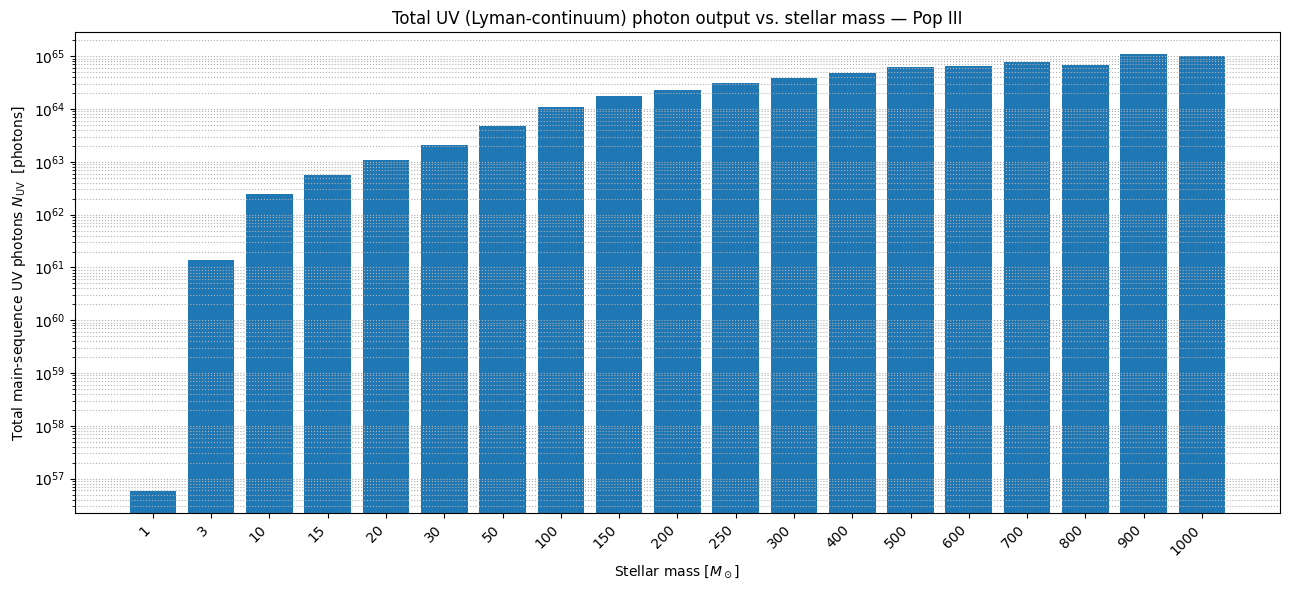

In [10]:
import re

EXCLUDE_MASSES = {87.0}

def discover_masses(profile_dir=PROFILE_DIR):
    """Scan profile_dir for profile_*.csv files and return the sorted list of
    unique masses [M_sun] found, deduplicating _1/_2 suffix variants (e.g.
    profile_150.0.csv and profile_150.0_1.csv both map to mass 150.0)."""
    pattern = re.compile(r"profile_(\d+(?:\.\d+)?)(?:_\d+)?\.csv$")
    masses = set()
    for f in profile_dir.glob("profile_*.csv"):
        m = pattern.match(f.name)
        if m:
            masses.add(float(m.group(1)))
    return sorted(masses)


all_masses    = discover_masses()
masses_to_run = [m for m in all_masses if m not in EXCLUDE_MASSES]
print(f"Discovered {len(all_masses)} unique masses; running {len(masses_to_run)} "
      f"(excluding {sorted(EXCLUDE_MASSES)}).")

N_UV_by_mass = {}
failed       = {}
for m in masses_to_run:
    try:
        N_UV_by_mass[m] = compute_total_UV_photons(m)
    except Exception as ex:
        failed[m] = f"{type(ex).__name__}: {ex}"
        print(f"  WARNING: mass={m:g} M_sun skipped — {failed[m]}")

print(f"\nSucceeded: {len(N_UV_by_mass)}/{len(masses_to_run)} masses")

masses_sorted = sorted(N_UV_by_mass)
N_values      = [N_UV_by_mass[m] for m in masses_sorted]

print("\nMass [M_sun]   N_UV [photons]")
for m, N in zip(masses_sorted, N_values):
    print(f"  {m:9.1f}    {N:.4e}")

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(masses_sorted))
ax.bar(x, N_values, color="tab:blue")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"{m:g}" for m in masses_sorted], rotation=45, ha="right")
ax.set_xlabel(r"Stellar mass [$M_\odot$]")
ax.set_ylabel(r"Total main-sequence UV photons $N_{\rm UV}$  [photons]")
ax.set_title("Total UV (Lyman-continuum) photon output vs. stellar mass — Pop III")
ax.grid(True, axis="y", which="both", ls=":")
plt.tight_layout()
plt.show()


## Log-Log Trend: $N_{\rm UV}$ vs. Mass

Same data as the bar chart above, but as a log-log line plot (reuses `masses_sorted` /
`N_values` from the previous cell) — this makes the *changing slope* visible directly,
rather than letting the huge (~8 dex) dynamic range visually flatten the high-mass tail.

The right panel shows the local power-law index $d\ln N_{\rm UV}/d\ln M$ (centered
finite difference in log-log space): steep ($\sim$3–4) at low mass, where $L$ and
$T_{\rm eff}$ still climb sharply with $M$; falling toward $\sim$1 above $\sim$100
$M_\odot$, consistent with these Pop III ZAMS models becoming Eddington-limited
($L\propto M$ rather than $M^{3.5}$) and $T_{\rm eff}$ plateauing.


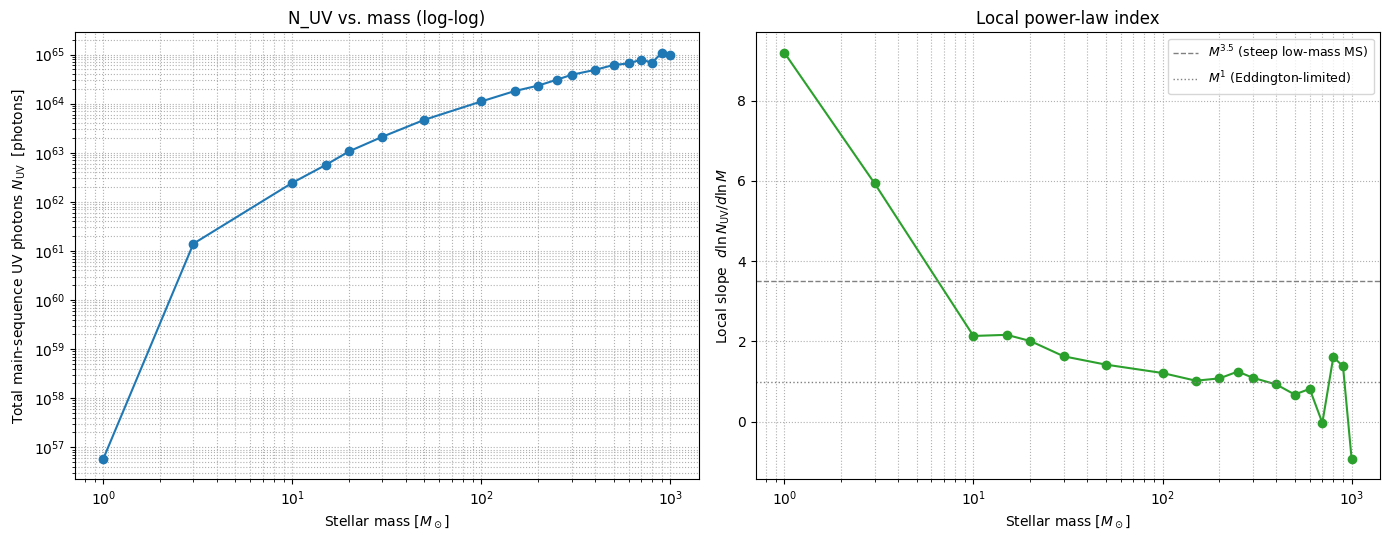

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].loglog(masses_sorted, N_values, marker="o", ls="-")
axes[0].set_xlabel(r"Stellar mass [$M_\odot$]")
axes[0].set_ylabel(r"Total main-sequence UV photons $N_{\rm UV}$  [photons]")
axes[0].set_title("N_UV vs. mass (log-log)")
axes[0].grid(True, which="both", ls=":")

log_slope = np.gradient(np.log(N_values), np.log(masses_sorted))
axes[1].semilogx(masses_sorted, log_slope, marker="o", color="tab:green")
axes[1].axhline(3.5, color="gray", ls="--", lw=1, label=r"$M^{3.5}$ (steep low-mass MS)")
axes[1].axhline(1.0, color="gray", ls=":", lw=1, label=r"$M^{1}$ (Eddington-limited)")
axes[1].set_xlabel(r"Stellar mass [$M_\odot$]")
axes[1].set_ylabel(r"Local slope  $d\ln N_{\rm UV}/d\ln M$")
axes[1].set_title("Local power-law index")
axes[1].legend(fontsize=9)
axes[1].grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()
